In [1]:
import pandas as pd
import numpy as np

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## Distribution Shifts in Rice Yield in Madhya Pradesh

In [2]:
yield_13_16_df = pd.read_csv('../../data/yield/DES-District-Data-For-2013-14-to-2015-16.csv')
yield_16_19_df = pd.read_csv('../../data/yield/DES-District-Data-For-2016-17-to-2018-19.csv')
yield_19_22_df = pd.read_csv('../../data/yield/DES-District-Data-For-2019-20-to-2021-22.csv')
yield_22_25_df = pd.read_csv('../../data/yield/DES-District-Data-For-2022-23-to-2024-25.csv')

filtered_df1 = yield_13_16_df[(yield_13_16_df['Season'] == 'Kharif')
                             & (yield_13_16_df['Crop'] == 'Rice')
                             & (yield_13_16_df['State'] == 'Madhya Pradesh')]
filtered_df2 = yield_16_19_df[(yield_16_19_df['Season'] == 'Kharif')
                                & (yield_16_19_df['Crop'] == 'Rice')
                                & (yield_16_19_df['State'] == 'Madhya Pradesh')]
filtered_df3 = yield_19_22_df[(yield_19_22_df['Season'] == 'Kharif')
                             & (yield_19_22_df['Crop'] == 'Rice')
                             & (yield_19_22_df['State'] == 'Madhya Pradesh')]
filtered_df4 = yield_22_25_df[(yield_22_25_df['Season'] == 'Kharif')
                             & (yield_22_25_df['Crop'] == 'Rice')
                             & (yield_22_25_df['State'] == 'Madhya Pradesh')]

filtered_df = filtered_df1[['District','Yield-2013-14', 'Yield-2014-15', 'Yield-2015-16']].merge(filtered_df2[['District', 'Yield-2016-17', 'Yield-2017-18', 'Yield-2018-19']], on='District', how='inner')
filtered_df = filtered_df.merge(filtered_df3[['District', 'Yield-2019-20', 'Yield-2020-21', 'Yield-2021-22']], on='District', how='inner')
filtered_df = filtered_df.merge(filtered_df4[['District', 'Yield-2022-23', 'Yield-2023-24', 'Yield-2024-25']], on='District', how='inner')
filtered_df

,District,Yield-2013-14,Yield-2014-15,Yield-2015-16,Yield-2016-17,Yield-2017-18,Yield-2018-19,Yield-2019-20,Yield-2020-21,Yield-2021-22,Yield-2022-23,Yield-2023-24,Yield-2024-25
0,Agar-Malwa,500.0,NaN,NaN,NaN,NaN,1000.0,NaN,534.0,NaN,2000.0,NaN,1736.0
1,Alirajpur,628.0,934.0,1066.0,1066.0,916.0,986.0,1184.0,1184.0,1254.0,1981.0,1441.0,1118.0
2,Anuppur,1814.0,1931.0,1609.0,1896.0,1599.0,1329.0,2036.0,2036.0,1503.0,2355.0,1486.0,1854.0
3,Ashoknagar,1658.0,1665.0,1665.0,NaN,1557.0,2006.0,2875.0,2875.0,2407.0,3610.0,2167.0,2355.0
4,Balaghat,1678.0,1834.0,1689.0,2483.0,1761.0,2009.0,2203.0,2203.0,1953.0,2930.0,1837.0,2123.0
5,Barwani,379.0,2000.0,660.0,660.0,609.0,322.0,394.0,395.0,1194.0,1892.0,1144.0,683.0
6,Betul,2255.0,2241.0,1778.0,1770.0,1758.0,1493.0,1813.0,1947.0,1880.0,2850.0,1755.0,2506.0
7,Bhind,4334.0,3445.0,4555.0,2190.0,1920.0,3580.0,4443.0,4300.0,3307.0,4318.0,2578.0,3031.0
8,Bhopal,1299.0,2545.0,2444.0,NaN,631.0,935.0,1217.0,1673.0,1540.0,3590.0,2185.0,2563.0
9,Burhanpur,989.0,NaN,NaN,NaN,825.0,1216.0,1724.0,1724.0,1385.0,1970.0,1192.0,1266.0


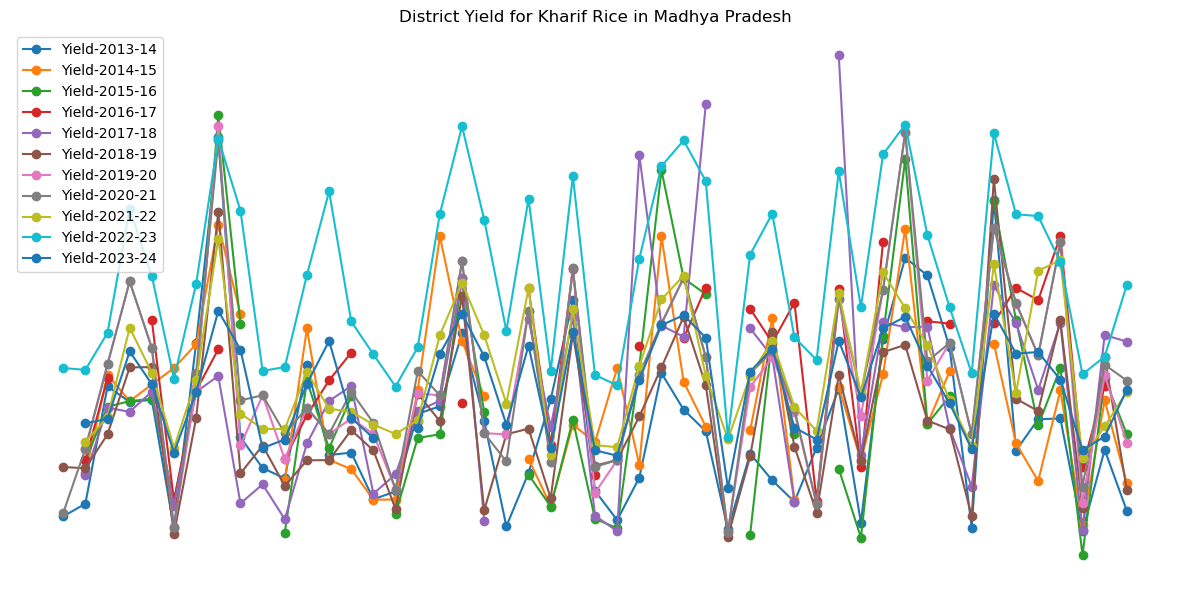

In [3]:
# Visualize district yield for 2022-23, 2023-24, and 2024-25
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
years = [('2013','14'), ('2014','15'), ('2015','16'), ('2016','17'), ('2017','18'), 
         ('2018','19'), ('2019','20'), ('2020','21'), ('2021','22'), ('2022','23'), 
         ('2023','24')]
for (start, end) in years:
    plt.plot(filtered_df['District'], filtered_df[f'Yield-{start}-{end}'], marker='o', label=f'Yield-{start}-{end}')
plt.xticks(rotation=45)
plt.xlabel('District')
plt.ylabel('Yield')
plt.title('District Yield for Kharif Rice in Madhya Pradesh')
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()

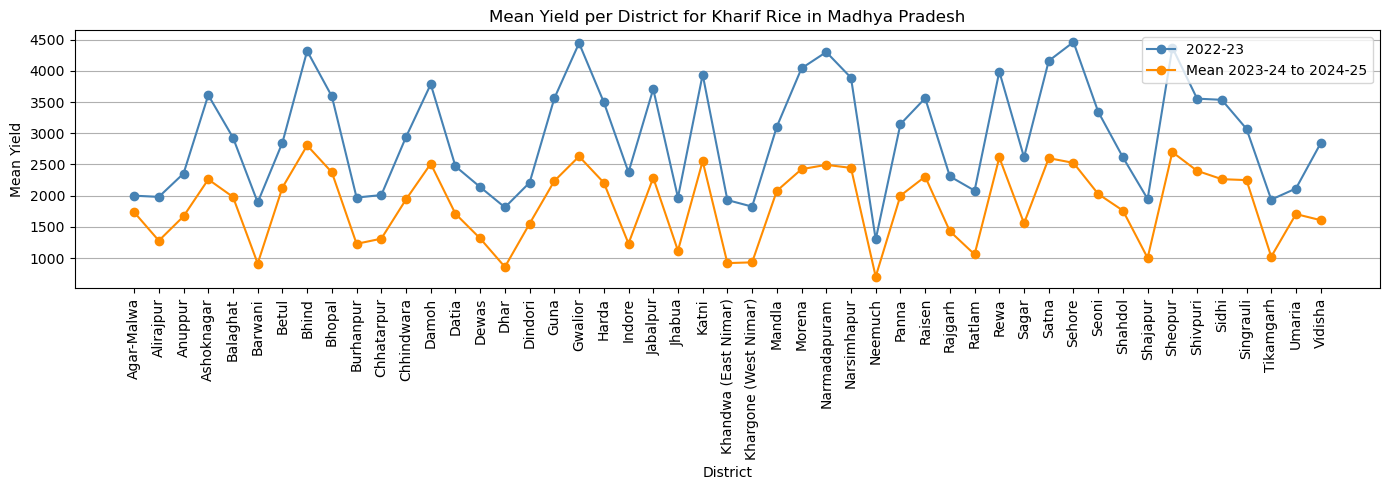

In [4]:
# years_range1 = [('2013','14'), ('2014','15'), ('2015','16'), ('2016','17'), ('2017','18'), 
#                 ('2018','19'), ('2019','20'), ('2020','21')]
# years_range2 = [('2021','22'), ('2022','23')]#, ('2023','24'), ('2024','25')]

years_range1 = [('2022', '23')]
years_range2 = [('2023', '24'), ('2024', '25')]

mean_r1 = filtered_df[[f'Yield-{s}-{e}' for s, e in years_range1]].mean(axis=1)
mean_r2 = filtered_df[[f'Yield-{s}-{e}' for s, e in years_range2]].mean(axis=1)

plt.figure(figsize=(14, 5))
plt.plot(filtered_df['District'], mean_r1, marker='o', color='steelblue', label='2022-23')
plt.plot(filtered_df['District'], mean_r2, marker='o', color='darkorange', label='Mean 2023-24 to 2024-25')
plt.xticks(rotation=90)
plt.xlabel('District')
plt.ylabel('Mean Yield')
plt.title('Mean Yield per District for Kharif Rice in Madhya Pradesh')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Is this distribution shift reflected on the peak gcvi?

/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_4540/319274483.py:30: RuntimeWarning: Mean of empty slice
  return np.nanmean(all_means, axis=0)
/var/folders/mn/mv85f3qn4b3fq8hnthx7qfdm0000gn/T/ipykernel_4540/319274483.py:30: RuntimeWarning: Mean of empty slice
  return np.nanmean(all_means, axis=0)


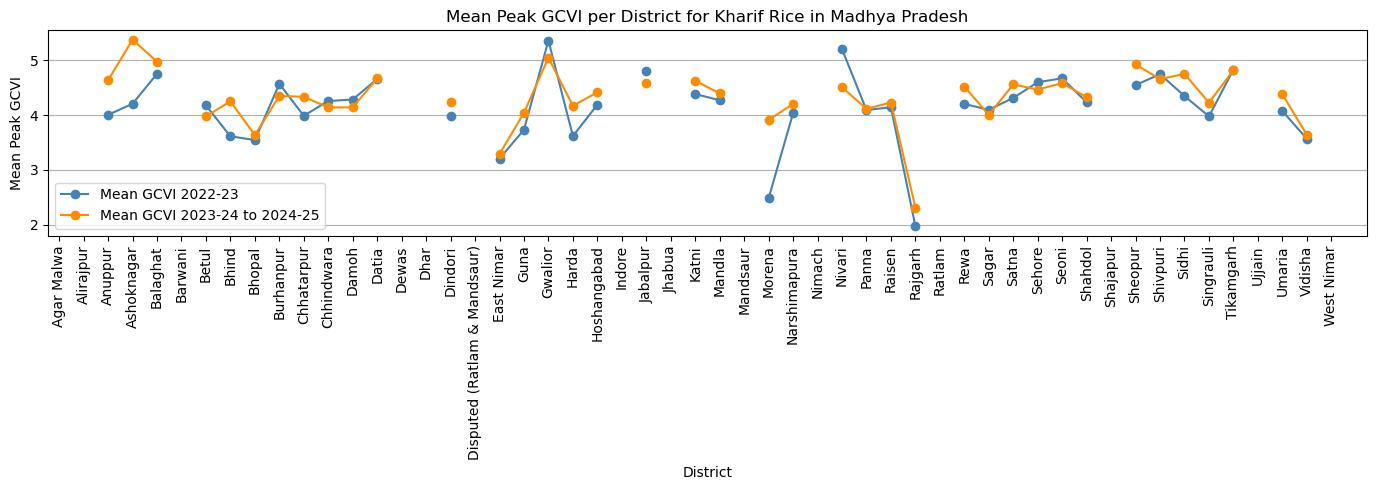

In [5]:
import rasterio
import tempfile
from rasterstats import zonal_stats
import geopandas as gpd

districts = gpd.read_file('../../data/mp_districts_GAUL/MP_Districts_GAUL.shp').to_crs('EPSG:4326')
districts['gaul2_name'] = districts['gaul2_name'].str.strip().str.title()

gcvi_range1 = range(2022, 2023)  # 2013-14 to 2020-21
gcvi_range2 = range(2023, 2025)  # 2021-22 to 2024-25

def mean_gcvi_per_district(years):
    all_means = []
    for year in years:
        tif_path = f'../../data/gcvi/peak_gcvi_kharif_{year}_mp_crop.tif'
        with rasterio.open(tif_path) as src:
            data = src.read(1).astype(float)
            nodata = src.nodata
            profile = src.profile
        data[np.isinf(data)] = np.nan
        if nodata is not None:
            data[data == nodata] = np.nan
        with tempfile.NamedTemporaryFile(suffix='.tif', delete=False) as tmp:
            tmp_path = tmp.name
        profile.update(nodata=np.nan)
        with rasterio.open(tmp_path, 'w', **profile) as dst:
            dst.write(data, 1)
        stats = zonal_stats(districts, tmp_path, stats='mean', nodata=np.nan)
        all_means.append([s['mean'] if s['mean'] is not None else np.nan for s in stats])
    return np.nanmean(all_means, axis=0)

gcvi_mean_r1 = mean_gcvi_per_district(gcvi_range1)
gcvi_mean_r2 = mean_gcvi_per_district(gcvi_range2)

plt.figure(figsize=(14, 5))
plt.plot(districts['gaul2_name'], gcvi_mean_r1, marker='o', color='steelblue', label='Mean GCVI 2022-23')
plt.plot(districts['gaul2_name'], gcvi_mean_r2, marker='o', color='darkorange', label='Mean GCVI 2023-24 to 2024-25')
plt.xticks(rotation=90)
plt.xlabel('District')
plt.ylabel('Mean Peak GCVI')
plt.title('Mean Peak GCVI per District for Kharif Rice in Madhya Pradesh')
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()